In [1]:
from tensorflow.keras.datasets import mnist
import numpy as np

2025-08-27 19:21:54.733805: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-27 19:21:54.778176: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-08-27 19:21:55.865105: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
train_images_with_noise_channels = np.concatenate(
    [train_images, np.random.random((len(train_images), 784))], axis=1
)

train_images_with_zeros_channels = np.concatenate(
    [
        train_images, np.zeros((len(train_images), 784))
    ], axis=1
)

Training the same model on Mnist

In [4]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

def get_model():
    model = Sequential(
        [
            Dense(512, activation="relu"),
            Dense(10, activation="softmax")
        ]
    )

    model.compile(
        optimizer = "rmsprop",
        loss = "sparse_categorical_crossentropy",
        metrics = ["accuracy"]
    )

    return model

In [5]:
model = get_model()

history_noise = model.fit(
    train_images_with_noise_channels, train_labels,
    epochs = 10, batch_size = 128, validation_split=0.2
)

2025-08-27 19:29:01.687623: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8134 - loss: 0.6110 - val_accuracy: 0.9048 - val_loss: 0.3175
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9218 - loss: 0.2527 - val_accuracy: 0.9417 - val_loss: 0.2003
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9477 - loss: 0.1671 - val_accuracy: 0.9501 - val_loss: 0.1700
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9637 - loss: 0.1181 - val_accuracy: 0.9323 - val_loss: 0.2148
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9723 - loss: 0.0873 - val_accuracy: 0.9477 - val_loss: 0.1722
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9803 - loss: 0.0630 - val_accuracy: 0.9554 - val_loss: 0.1545
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9850 - loss: 0.0471 - val_accuracy: 0.9524 - val_loss: 0.1725
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9879 - loss: 0.0363 - val_accu

In [6]:
model = get_model()

history_zeros = model.fit(
    train_images_with_zeros_channels, train_labels,
    epochs = 10, batch_size = 128, validation_split = 0.2
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9144 - loss: 0.2961 - val_accuracy: 0.9572 - val_loss: 0.1491
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9641 - loss: 0.1242 - val_accuracy: 0.9643 - val_loss: 0.1168
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9757 - loss: 0.0817 - val_accuracy: 0.9718 - val_loss: 0.0930
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9822 - loss: 0.0597 - val_accuracy: 0.9726 - val_loss: 0.0923
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9871 - loss: 0.0446 - val_accuracy: 0.9768 - val_loss: 0.0793
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9902 - loss: 0.0336 - val_accuracy: 0.9768 - val_loss: 0.0798
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9924 - loss: 0.0260 - val_accuracy: 0.9783 - val_loss: 0.0753
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9949 - loss: 0.0187 - val_accu

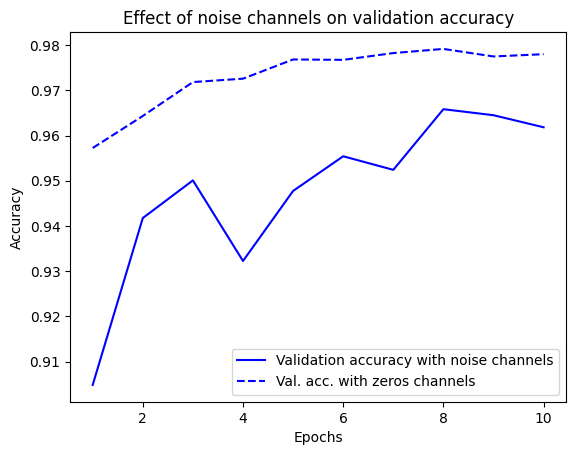

In [7]:
import matplotlib.pyplot as plt

val_acc_noise = history_noise.history["val_accuracy"]
val_acc_zeros = history_zeros.history["val_accuracy"]

epochs = range(1, 11)

plt.plot(epochs, val_acc_noise, 'b-',
         label="Validation accuracy with noise channels"
         )

plt.plot(
    epochs, val_acc_zeros, 'b--', label="Val. acc. with zeros channels"
)

plt.title("Effect of noise channels on validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

The nature of generalization in deep learning

In [8]:
random_train_labels = train_labels[:]
np.random.shuffle(random_train_labels)

model = Sequential(
    [
        Dense(512, activation='relu'),
        Dense(10, activation='softmax')
    ]
)

model.compile(
    optimizer = "rmsprop",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

model.fit(
    train_images, random_train_labels,
    epochs = 100, batch_size = 128, validation_split = 0.2
)

Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1025 - loss: 2.3151 - val_accuracy: 0.1077 - val_loss: 2.3046
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1153 - loss: 2.2995 - val_accuracy: 0.1057 - val_loss: 2.3150
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1264 - loss: 2.2916 - val_accuracy: 0.1001 - val_loss: 2.3168
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1404 - loss: 2.2787 - val_accuracy: 0.1039 - val_loss: 2.3233
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1534 - loss: 2.2626 - val_accuracy: 0.1027 - val_loss: 2.3345
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1668 - loss: 2.2432 - val_accuracy: 0.1068 - val_loss: 2.3444
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1837 - loss: 2.2188 - val_accuracy: 0.1008 - val_loss: 2.3605
Epoch 8/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1963 - loss: 2.1915 - val_accu

## Evaluating machine-learning models

training, validation, and test sets

simple hold-out validation

k-fold validation

Interated k-fold validation with shuffling

### training with an incorrectly high learning rate

In [9]:
from tensorflow.keras.optimizers import RMSprop

model = Sequential(
    [
        Dense(512, activation='relu'),
        Dense(10, activation='softmax')
    ]
)

model.compile(
    optimizer = RMSprop(1.),
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

model.fit(
    train_images, train_labels,
    epochs=10, batch_size = 128, validation_split=0.2
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1004 - loss: 370.2725 - val_accuracy: 0.0968 - val_loss: 2.5549
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1026 - loss: 2.4475 - val_accuracy: 0.0890 - val_loss: 2.4842
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1034 - loss: 2.4491 - val_accuracy: 0.0957 - val_loss: 2.4728
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1000 - loss: 2.4531 - val_accuracy: 0.0890 - val_loss: 2.4624
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1014 - loss: 2.4477 - val_accuracy: 0.0958 - val_loss: 2.3895
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1025 - loss: 2.4495 - val_accuracy: 0.0890 - val_loss: 2.4054
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1011 - loss: 2.4519 - val_accuracy: 0.0990 - val_loss: 2.5493
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1014 - loss: 2.4482 - val_accuracy: 

Simple Logistic Regression on MNIST

In [11]:
model = Sequential([Dense(10, activation="softmax")])

model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

history_small_model = model.fit(
    train_images, train_labels,
    epochs = 20, batch_size = 128, validation_split = 0.2
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.1033 - loss: 2.3273 - val_accuracy: 0.1003 - val_loss: 2.3188
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 998us/step - accuracy: 0.1085 - loss: 2.3111 - val_accuracy: 0.1043 - val_loss: 2.3191
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1150 - loss: 2.3060 - val_accuracy: 0.1022 - val_loss: 2.3179
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1184 - loss: 2.3017 - val_accuracy: 0.1023 - val_loss: 2.3219
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1218 - loss: 2.2982 - val_accuracy: 0.1052 - val_loss: 2.3226
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1241 - loss: 2.2954 - val_accuracy: 0.1032 - val_loss: 2.3233
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1270 - loss: 2.2935 - val_accuracy: 0.1028 - val_loss: 2.3261
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1265 - loss: 2.2915 - val_accuracy: 

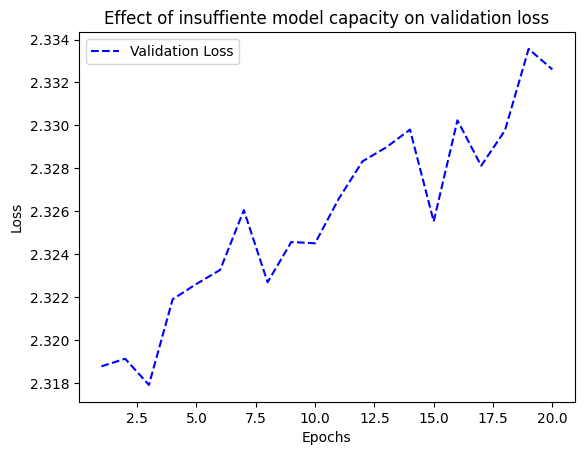

In [12]:
val_loss = history_small_model.history["val_loss"]
epochs = range(1, 21)

plt.plot(epochs, val_loss, "b--", label="Validation Loss")
plt.title("Effect of insuffiente model capacity on validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

### Improving generalization

dataset curation 

feature engineering

using early stopping

regularizing your model

reducing the networks size

In [13]:
from tensorflow.keras.datasets import imdb

In [14]:
(train_data, train_labels), _ = imdb.load_data(num_words=1000)

def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))

    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.
    
    return results

train_data = vectorize_sequences(train_data)

In [15]:
model = Sequential(
    [
        Dense(16, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ]
)

model.compile(
    optimizer = "rmsprop",
    loss = "binary_crossentropy",
    metrics = ["accuracy"]
)

model.fit(
    train_data, train_labels,
    epochs = 20, batch_size = 512, validation_split =0.4
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7426 - loss: 0.6143 - val_accuracy: 0.8168 - val_loss: 0.5306
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8381 - loss: 0.4721 - val_accuracy: 0.8372 - val_loss: 0.4306
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8513 - loss: 0.3937 - val_accuracy: 0.8452 - val_loss: 0.3838
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8597 - loss: 0.3495 - val_accuracy: 0.8556 - val_loss: 0.3528
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8669 - loss: 0.3268 - val_accuracy: 0.8535 - val_loss: 0.3485
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8710 - loss: 0.3129 - val_accuracy: 0.8386 - val_loss: 0.3753
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8738 - loss: 0.3061 - val_accuracy: 0.8574 - val_loss: 0.3378
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8775 - loss: 0.3009 - val_accuracy: 0.8596 - v

### Adding L2 weight regularization to the model

In [18]:
from tensorflow.keras import regularizers as L2

model = Sequential(
    [
        Dense(16, kernel_regularizer = L2.l2(0.002), activation= 'relu'),
        Dense(16, kernel_regularizer = L2.l2(0.002), activation='relu'),
        Dense(1, activation='sigmoid')
    ]
)

model.compile(
    optimizer = "rmsprop",
    loss = 'binary_crossentropy',
    metrics = ["accuracy"]
)

history_l2 = model.fit(
    train_data, train_labels,
    epochs = 20, batch_size = 512, validation_split=0.4
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.7418 - loss: 0.6436 - val_accuracy: 0.8161 - val_loss: 0.5319
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8407 - loss: 0.4746 - val_accuracy: 0.8465 - val_loss: 0.4430
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8577 - loss: 0.4101 - val_accuracy: 0.8581 - val_loss: 0.4023
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8621 - loss: 0.3816 - val_accuracy: 0.8455 - val_loss: 0.4151
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8669 - loss: 0.3683 - val_accuracy: 0.8595 - val_loss: 0.3883
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8670 - loss: 0.3616 - val_accuracy: 0.8606 - val_loss: 0.3812
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8719 - loss: 0.3572 - val_accuracy: 0.8549 - val_loss: 0.3911
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8749 - loss: 0.3529 - val_accuracy: 0.8505 - v

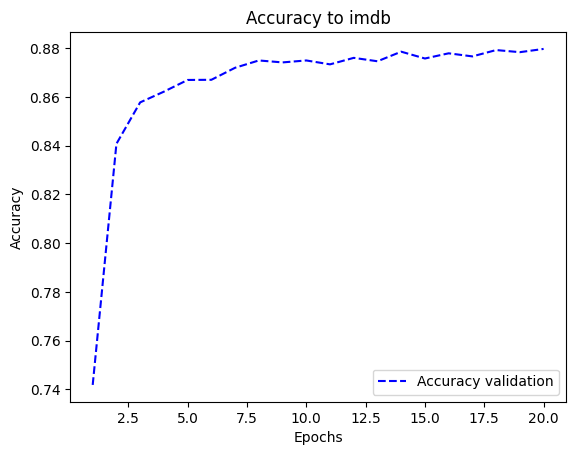

In [19]:
acc_hist = history_l2.history["accuracy"]

plt.plot(epochs, acc_hist, "b--", label="Accuracy validation")
plt.title("Accuracy to imdb")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [20]:


# Different weight regularizers available in Keras

from tensorflow.keras import regularizers
from tensorflow.keras.layers import Dropout

regularizers.l1(0.001)
regularizers.l1_l2(l1=0.001, l2=0.001)

# Adding dropout
# Adding dropout to the IMDB model

model = Sequential([
    Dense(16, activation="relu"),
    Dropout(0.5),
    Dense(16, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])
model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

history_dropout = model.fit(
    train_data, train_labels,
    epochs=20, batch_size=512, validation_split=0.4)



Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.6108 - loss: 0.6549 - val_accuracy: 0.8150 - val_loss: 0.5754
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7105 - loss: 0.5775 - val_accuracy: 0.8423 - val_loss: 0.4985
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7686 - loss: 0.5148 - val_accuracy: 0.8463 - val_loss: 0.4273
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7933 - loss: 0.4719 - val_accuracy: 0.8498 - val_loss: 0.3991
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8143 - loss: 0.4382 - val_accuracy: 0.8540 - val_loss: 0.3664
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8321 - loss: 0.4132 - val_accuracy: 0.8579 - val_loss: 0.3526
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8425 - loss: 0.3929 - val_accuracy: 0.8601 - val_loss: 0.3381
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8539 - loss: 0.3726 - val_accuracy: 0.8587 - v